# Problema di regressione sulla feature `aps`

Al solito ripercorriamo la scaletta delle operazioni da fare nel pre-processing:
1. Rimozione colonne sparse;
2. Rimozione fattori prognostici;
3. Splitting;
4. Imputazione;
5. Encoding;
6. Scaling;
7. Analisi di correlazione;
8. Feature Selection;
9. Addestramento del modello

In [2]:
import numpy as np
import pandas as pd

from sklearn._config import set_config
set_config(transform_output="pandas")

In [3]:
dd = pd.read_csv("data/dataset_esercitazione.csv")
dd

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,sps,aps,surv2m,surv6m,hday,diabetes,dementia,ca,prg2m,prg6m,dnr,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc,death
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,NaN,7.000000,other,33.898438,20.0,0.262939,0.036995,1,0,0,metastatic,0.50,0.250,no dnr,5.0,97.0,6.000000,69.0,22.0,36.00000,388.00000,1.799805,0.199982,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,7.000000,0
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,NaN,29.000000,white,52.695312,74.0,0.001000,0.000000,3,0,0,no,0.00,0.000,NaN,NaN,43.0,17.097656,112.0,34.0,34.59375,98.00000,NaN,NaN,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,1.000000,1
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,NaN,13.000000,white,20.500000,45.0,0.790894,0.664917,4,0,0,no,0.75,0.500,no dnr,17.0,70.0,8.500000,88.0,28.0,37.39844,231.65625,NaN,2.199707,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,0.000000,1
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,NaN,7.000000,white,20.097656,19.0,0.698975,0.411987,1,0,0,metastatic,0.90,0.500,no dnr,3.0,75.0,9.099609,88.0,32.0,35.00000,NaN,NaN,NaN,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,1
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,NaN,18.666656,white,23.500000,30.0,0.634888,0.532959,3,0,0,no,0.90,0.900,no dnr,16.0,59.0,13.500000,112.0,20.0,37.89844,173.31250,NaN,NaN,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,2.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,66.07300,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,8.0,NaN,0.0,52870.0,34329.3125,32042.7500,20.333328,white,16.296875,22.0,0.852905,0.801880,13,0,0,no,0.80,0.512,no dnr,23.0,109.0,7.399414,104.0,22.0,35.69531,280.00000,3.699707,0.399963,1.099854,131.0,7.459961,188.0,21.0,NaN,NaN,0.0,0.000000,0
9101,55.15399,female,Coma,Coma,1,11.0,NaN,41.0,35377.0,23558.5000,22131.0469,18.000000,white,25.796875,31.0,0.553955,0.485962,1,0,0,no,0.50,0.500,no dnr,29.0,43.0,NaN,0.0,8.0,38.59375,218.50000,NaN,NaN,5.899414,135.0,7.289062,190.0,49.0,0.0,NaN,0.0,0.000000,0
9102,70.38196,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,0.0,46564.0,31409.0156,31131.2500,23.000000,white,22.699219,39.0,0.741943,0.660889,18,0,0,no,0.90,0.800,no dnr,8.0,111.0,8.398438,83.0,24.0,36.69531,180.00000,NaN,0.399963,2.699707,139.0,7.379883,189.0,60.0,3900.0,NaN,NaN,2.525391,0
9103,47.01999,male,MOSF w/Malig,ARF/MOSF,1,13.0,NaN,0.0,58439.0,NaN,NaN,35.500000,white,40.195312,51.0,0.177979,0.091995,22,0,0,yes,0.09,0.090,dnr after sadm,5.0,99.0,7.599609,110.0,24.0,36.39844,428.56250,1.199951,0.399963,3.500000,135.0,7.469727,246.0,55.0,NaN,NaN,0.0,0.000000,1


In [4]:
col_sparse = dd.columns[dd.isna().mean() > 0.5]
col_sparse

Index(['urine', 'adlp'], dtype='object')

In [5]:
dd = dd.drop(columns=col_sparse)
dd.shape

(9105, 41)

Rimozione dei fattori prognostici: `sps`, `death`, `dzgroup`, `dzclass`

In [6]:
diag_to_remove = ['sps', 'dzgroup', 'dzclass', 'death']
dd = dd.drop(columns = diag_to_remove)

In [7]:
dd.shape

(9105, 37)

In [8]:
from sklearn.model_selection import train_test_split

X = dd.drop(columns = "aps")
y = dd[["aps"]]

In [9]:
y.isna().mean()

aps    0.00011
dtype: float64

In [10]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size = 0.05, random_state = 42)

In [11]:
# Imputazione 
from sklearn.impute import SimpleImputer

imp1 = SimpleImputer(strategy="median")
imp2 = SimpleImputer(strategy="constant", fill_value="unknown")
imp3 = SimpleImputer(strategy="median")

num_cols = X_tr.select_dtypes(include = "number").columns
cat_cols = X_tr.select_dtypes(exclude = "number").columns

In [12]:
X_tr[num_cols] = imp1.fit_transform(X_tr[num_cols])
X_tr[cat_cols] = imp2.fit_transform(X_tr[cat_cols])

X_te[num_cols] = imp1.transform(X_te[num_cols])
X_te[cat_cols] = imp2.transform(X_te[cat_cols])

y_tr = imp3.fit_transform(y_tr)
y_te = imp3.transform(y_te)

In [13]:
# Encoding
from sklearn.preprocessing import OrdinalEncoder

X_tr[cat_cols].apply(lambda x:x.unique())

sex                                          [male, female]
income     [unknown, under $11k, $11-$25k, $25-$50k, >$50k]
race        [white, black, hispanic, other, unknown, asian]
ca                                    [no, metastatic, yes]
dnr       [dnr after sadm, no dnr, dnr before sadm, unkn...
dtype: object

In [14]:
ord_cols  = ['income', 'ca']
ord_cats = [['unknown', 'under $11k', '$11-$25k', '$25-$50k', '>$50k'], ['no', 'yes', 'metastatic']]

cat_cols = cat_cols.drop(ord_cols)
cat_cols

Index(['sex', 'race', 'dnr'], dtype='object')

In [15]:
oe = OrdinalEncoder()
oe1 = OrdinalEncoder(categories = ord_cats)

X_tr[cat_cols] = oe.fit_transform(X_tr[cat_cols])
X_tr[ord_cols] = oe1.fit_transform(X_tr[ord_cols])

X_te[cat_cols] = oe.transform(X_te[cat_cols])
X_te[ord_cols] = oe1.transform(X_te[ord_cols])


In [16]:
X_tr.shape

(8649, 36)

**IMPORTANTE:** la procedura di standardizzazione va eseguita solo e soltanto sulle feature, mai sul target!

In [17]:
# Scaling delle sole feature
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_tr = sc.fit_transform(X_tr)
X_te = sc.transform(X_te)

**IMPORTANTE:** è importante tenere presente che per eseguire l'analisi di correlazione con il target, è richiesto che la y sia un oggetto di tipo Series, mentre in precedenza per applicare l'imputer era necessario che fosse un DataFrame. A questo punto quindi ritrasformiamo l'oggetto in Series.
Ricorda:
- La sintassi `dd[['target']]` estrae un DataFrame;
- La sintassi `dd['target']` estrae una Series.


In [18]:
# Correlazione con risposta
y_tr = y_tr["aps"]
y_te = y_te["aps"]

soglia = 0.1

col_to_remove = (
    X_tr.corrwith(y_tr) 
    .abs()
    .sort_values(ascending = False)
    .loc[lambda x: x < soglia]
    .index
)

col_to_remove

Index(['wblc', 'diabetes', 'ph', 'temp', 'bun', 'adls', 'income', 'race',
       'sod', 'age', 'glucose', 'num.co', 'dementia', 'sex', 'edu'],
      dtype='object')

In [19]:
len(col_to_remove)

15

In [20]:
X_tr = X_tr.drop(columns=col_to_remove)
X_te = X_te.drop(columns=col_to_remove)

In [21]:
soglia2 = 0.8

coppie = (
    X_tr.corr()
    .abs()
    .map(lambda x: x > soglia2)
    .unstack()
    .reset_index()
)

coppie.columns = ['var1', 'var2', 'high_corr']
coppie = coppie.loc[lambda x: x['high_corr'] & (x['var1'] < x['var2'])]
coppie

,var1,var2,high_corr
111,surv2m,surv6m,True
199,prg2m,prg6m,True


In [22]:
# Combinazione lineare
X_tr['survmean'] = X_tr[['surv2m', 'surv6m']].mean(axis = 1)
X_tr['prgmean'] = X_tr[['prg2m', 'prg6m']].mean(axis = 1)

X_te['survmean'] = X_te[['surv2m', 'surv6m']].mean(axis = 1)
X_te['prgmean'] = X_te[['prg2m', 'prg6m']].mean(axis = 1)

X_tr = X_tr.drop(columns = ['surv2m', 'surv6m', 'prg2m', 'prg6m'])
X_te = X_te.drop(columns = ['surv2m', 'surv6m', 'prg2m', 'prg6m'])

In [23]:
# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif
sel = SelectKBest(score_func=f_classif, k = "all")
sel.fit(X_tr, y_tr)
sel.pvalues_

array([3.00690345e-131, 9.20236344e-159, 9.96232077e-139, 2.14154231e-096,
       0.00000000e+000, 1.52213342e-092, 3.37788425e-202, 7.88631008e-117,
       4.96575161e-037, 1.50065913e-030, 1.85802751e-034, 9.85711783e-014,
       8.62395753e-014, 2.26091261e-024, 2.04841289e-094, 5.57820107e-074,
       4.46763666e-008, 0.00000000e+000, 4.92948493e-157])

In [24]:
X_tr.shape

(8649, 19)

In [25]:
# Prendo la metà 
skb = SelectKBest(score_func=f_classif, k = 10)
X_tr_skb = skb.fit_transform(X_tr, y_tr)
X_te_skb = skb.transform(X_te)

In [26]:
X_tr_skb.columns

Index(['scoma', 'charges', 'totcst', 'totmcst', 'avtisst', 'ca', 'dnr', 'bili',
       'survmean', 'prgmean'],
      dtype='object')

In [27]:
X_te_skb.columns

Index(['scoma', 'charges', 'totcst', 'totmcst', 'avtisst', 'ca', 'dnr', 'bili',
       'survmean', 'prgmean'],
      dtype='object')

## Regressione

### RandomForestRegressor/ Lasso/ Ridge/ LinearRegression/ SVR

1. criterion: “squared_error”, “absolute_error”
2. min_samples_split: 2, 5, 10
3. max_features: “sqrt”, 5

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.model_selection import GridSearchCV

In [29]:
rf = RandomForestRegressor(n_estimators=20, random_state=42)
param_grid = {
    'criterion': ['squared_error', 'absolute_error'],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 5]
}

grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=4)
grid_rf.fit(X_tr_skb, y_tr)
print("Miglior modello:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
y_pred = best_rf.predict(X_te_skb)

Miglior modello: {'criterion': 'absolute_error', 'max_features': 5, 'min_samples_split': 10}


In [30]:
# Potremmo fittare un nuovo RandomForest con i parametri trovati e 100 alberi
rf_final = RandomForestRegressor(n_estimators=100, criterion="absolute_error", max_features= 5, min_samples_split=10, random_state=42)
rf_final.fit(X_tr_skb, y_tr)

RandomForestRegressor(criterion='absolute_error', max_features=5,
                      min_samples_split=10, random_state=42)

In [31]:
y_pred2 = rf_final.predict(X_te_skb)

In [ ]:
grid_rf.best_score_ # su 20 alberi

np.float64(0.6346533949309607)

In [ ]:
# Valutare il regressore con metrica R2
from sklearn.metrics import r2_score

# Calcolo del punteggio R2 sul Test Set
r2_score(y_te, y_pred2)

R2 Score sul Test Set: 0.6962


Il modello non ha una buona performance. 

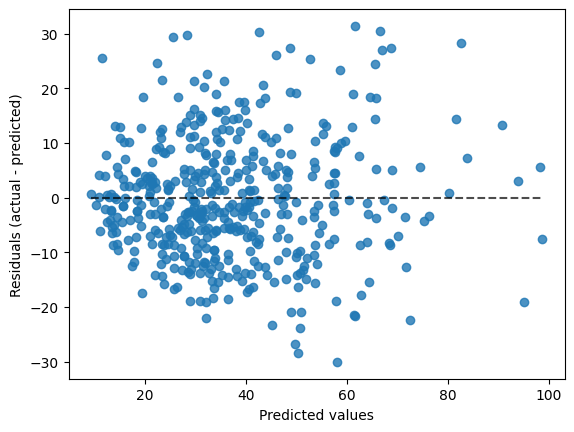

In [33]:
from sklearn.metrics import PredictionErrorDisplay
import matplotlib.pyplot as plt

PredictionErrorDisplay.from_estimator(rf_final,
                                      X_te_skb,
                                      y_te,
                                      kind = "residual_vs_predicted")
plt.show()

### Lasso Regression

In [34]:
from sklearn.linear_model import Lasso

In [38]:
param = {
    "tol": [0.05, 0.001, 0.0001],
    "alpha": [0.001, 0.01, 1, 10]
}
las = Lasso(random_state=42)

gs = GridSearchCV(las, 
             param_grid=param,
             scoring = "r2", # di default altrimenti "neg_mean_squared_error"
             cv = 5, 
             n_jobs=4)

gs.fit(X_tr_skb, y_tr)
gs.best_params_

{'alpha': 0.01, 'tol': 0.0001}

In [42]:
print(gs.best_score_)

0.6014644159367105


In [47]:
y_predls = gs.predict(X_te_skb)

In [49]:
r2_score(y_te, y_predls)

0.6452292652054483

## Ridge 

In [43]:
from sklearn.linear_model import Ridge
rid = Ridge(random_state=42)

param = {
    'alpha': [0.001, 0.01, 1, 10],
    'tol': [0.001, 0.01, 0.05]
}

gsr = GridSearchCV(rid, param_grid=param,
                   scoring = "r2",
                   cv = 5,
                   n_jobs = 3)

gsr.fit(X_tr_skb, y_tr)
gsr.best_params_

{'alpha': 1, 'tol': 0.001}

In [45]:
y_pred = gsr.predict(X_te_skb)

In [ ]:
r2_score(y_te, y_pred) #r2 sul test set


0.64526762500645